# Trabajo Práctico 2 - Problema 1: Diagnóstico de Cáncer de Mama

## Introducción

Este notebook aborda el problema de clasificación binaria para el diagnóstico de tumores mamarios (benignos vs malignos) utilizando regresión logística implementada desde cero.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import *
from metrics import *
from models import *
from utils import *

## 1. Carga y Exploración de Datos

In [2]:
from IPython.display import Markdown, display

balanced_dev = pd.read_csv('data/cell_diagnosis_dev.csv')
balanced_test = pd.read_csv('data/cell_diagnosis_test.csv')
imbalanced_dev = pd.read_csv('data/cell_diagnosis_dev_imbalanced.csv')
imbalanced_test = pd.read_csv('data/cell_diagnosis_test_imbalanced.csv')

def show_basic_info(df, name):
    display(Markdown(f"### {name}"))
    display(Markdown(f"**Forma del dataset**: {df.shape}"))
    display(Markdown("**Información del dataset**:"))
    display(df.info())
    display(Markdown("**Estadísticas descriptivas**:"))
    display(df.describe())
    display(Markdown("**Distribución de clases**:"))
    display(df['Diagnosis'].value_counts(normalize=True))

show_basic_info(balanced_dev, "Datos Balanceados (Desarrollo)")

### Datos Balanceados (Desarrollo)

**Forma del dataset**: (1663, 15)

**Información del dataset**:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CellSize             1333 non-null   float64
 1   CellShape            1347 non-null   float64
 2   NucleusDensity       1362 non-null   float64
 3   ChromatinTexture     1366 non-null   float64
 4   CytoplasmSize        1347 non-null   float64
 5   CellAdhesion         1369 non-null   float64
 6   MitosisRate          1343 non-null   float64
 7   NuclearMembrane      1343 non-null   float64
 8   GrowthFactor         1359 non-null   float64
 9   OxygenSaturation     1375 non-null   float64
 10  Vascularization      1347 non-null   float64
 11  InflammationMarkers  1358 non-null   float64
 12  Diagnosis            1663 non-null   float64
 13  CellType             1407 non-null   object 
 14  GeneticMutation      1663 non-null   object 
dtypes: float64(13), object(2)
memory usage

None

**Estadísticas descriptivas**:

,CellSize,CellShape,NucleusDensity,ChromatinTexture,CytoplasmSize,CellAdhesion,MitosisRate,NuclearMembrane,GrowthFactor,OxygenSaturation,Vascularization,InflammationMarkers,Diagnosis
count,1333.000000,1347.000000,1362.000000,1366.000000,1347.000000,1369.000000,1343.000000,1343.000000,1359.000000,1375.000000,1347.000000,1358.000000,1663.000000
mean,83.247087,0.598657,2.097344,26.094973,33.989815,0.548800,5.326484,2.825365,74.126375,93.199374,5.968017,47.725954,0.450391
std,100.316719,0.565438,4.987573,24.842157,32.809627,0.612232,11.572456,2.697956,77.819461,82.574244,5.649530,44.133737,0.497683
min,-100.000000,-1.413038,-3.000000,10.000000,5.000000,-4.461755,-50.000000,-3.438990,-50.000000,-10.000000,-0.997057,0.000000,0.000000
25%,66.572149,0.479758,1.397010,21.279126,26.304514,0.456400,2.776731,2.254502,58.170436,79.130570,4.782475,37.513981,0.000000
50%,69.704323,0.498832,1.445035,22.066810,28.448318,0.474836,3.080247,2.414464,60.993969,79.987328,5.068099,40.859154,0.000000
75%,72.653147,0.523018,1.485651,22.823319,30.506774,0.494613,3.423066,2.534339,63.041642,80.986905,5.346464,43.913527,1.000000
max,1000.000000,5.048566,50.000000,263.793425,299.350559,5.029925,100.000000,24.871762,563.622684,807.181058,54.512433,440.902261,1.000000


**Distribución de clases**:

Diagnosis
0.0    0.549609
1.0    0.450391
Name: proportion, dtype: float64

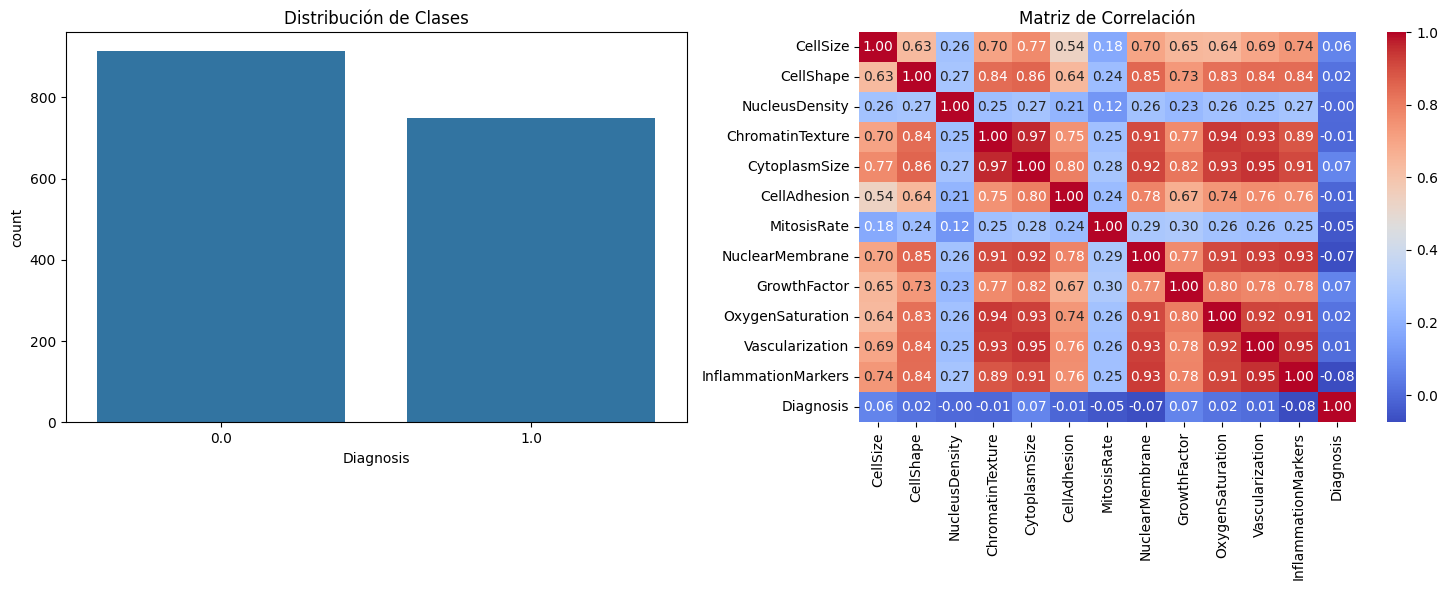

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribución de clases
sns.countplot(x='Diagnosis', data=balanced_dev, ax=axes[0])
axes[0].set_title('Distribución de Clases')

# Correlación entre características
numeric_df = balanced_dev.select_dtypes(include=[np.number])  # Select only numeric columns
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1])
axes[1].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

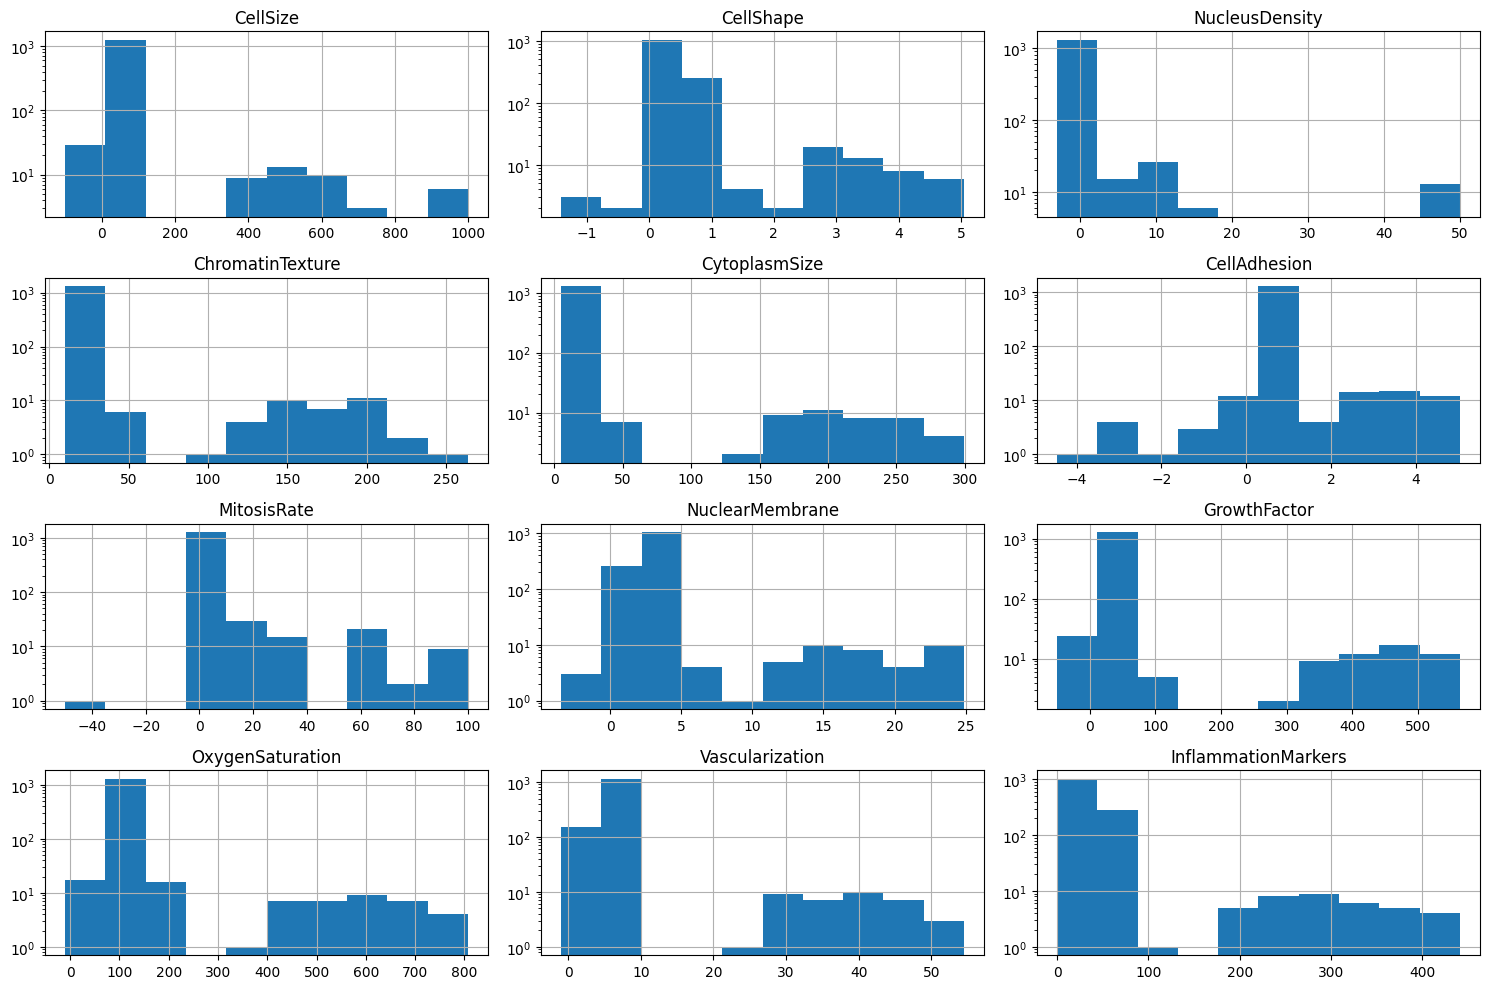

In [4]:
numeric_df.drop(columns=["Diagnosis"]).hist(figsize=(15, 10), log=True)
plt.tight_layout()
plt.show()

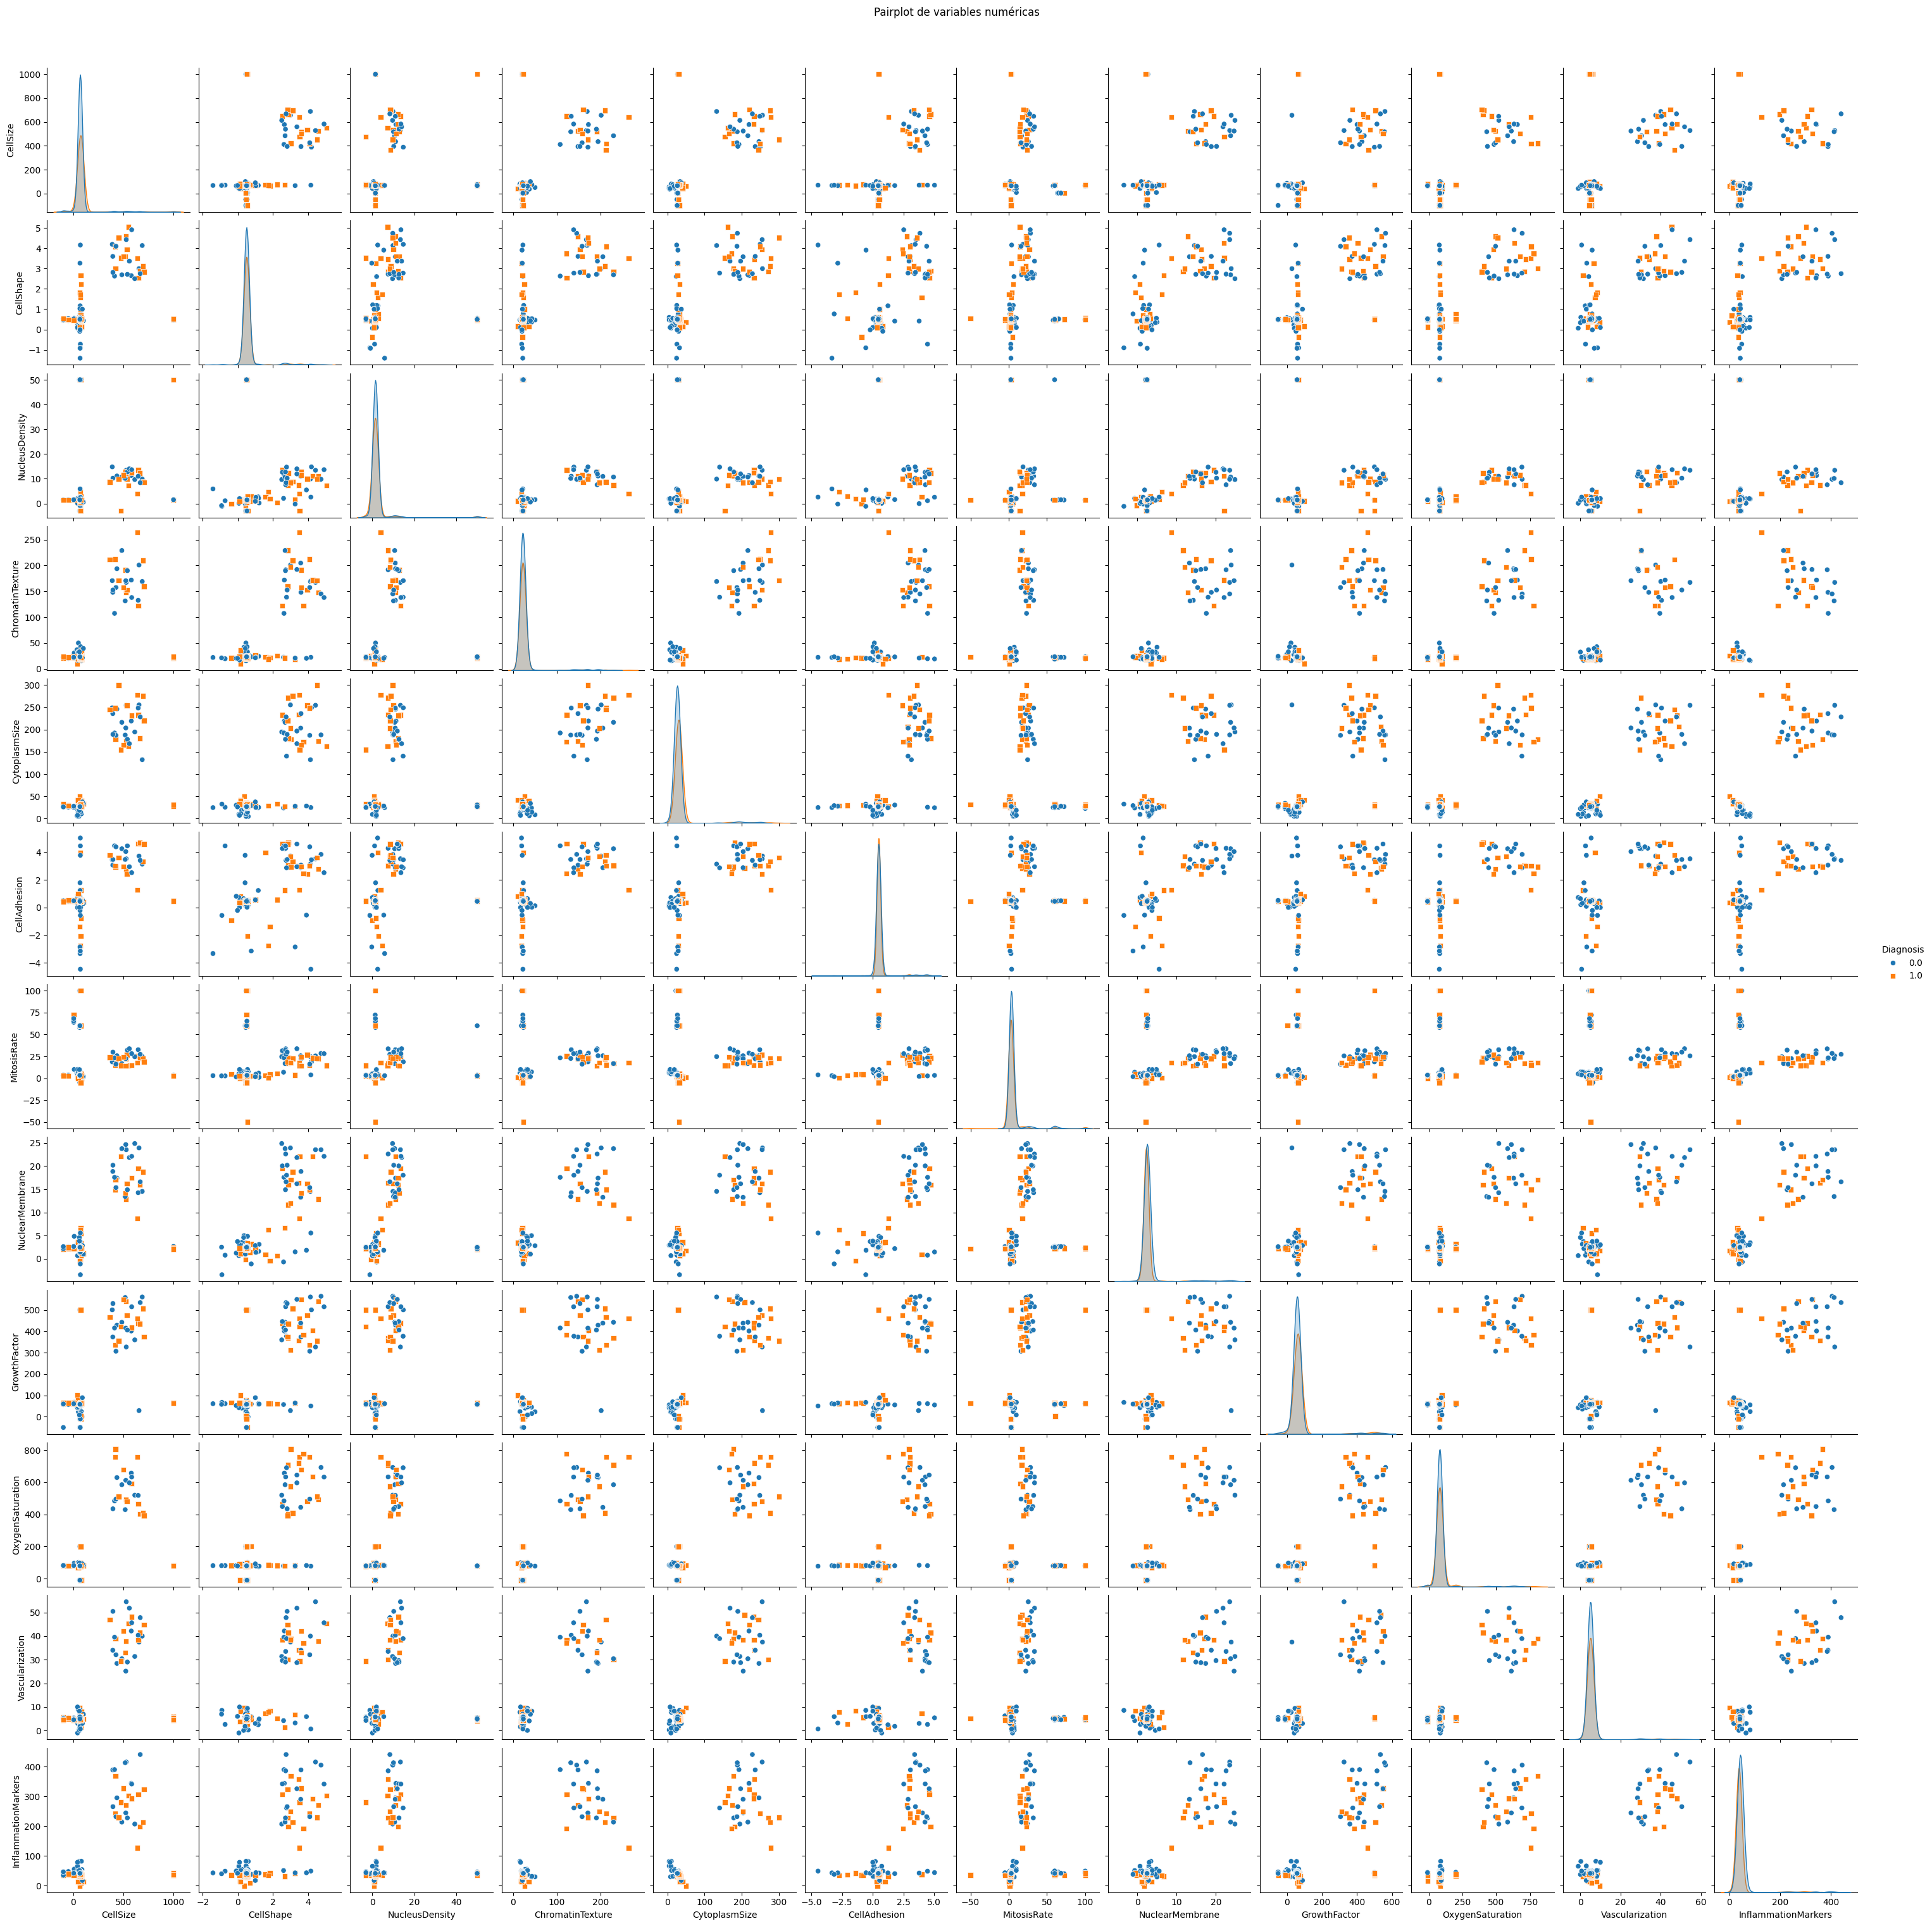

In [5]:
# pd.plotting.scatter_matrix(numeric_df.drop(columns=["Diagnosis"]), figsize=(15, 15), diagonal='kde')
# plt.suptitle("Matriz de dispersión de variables numéricas", y=0.9)
# plt.show()

sns.pairplot(numeric_df, hue="Diagnosis", diag_kind="kde", markers=["o", "s"])
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()

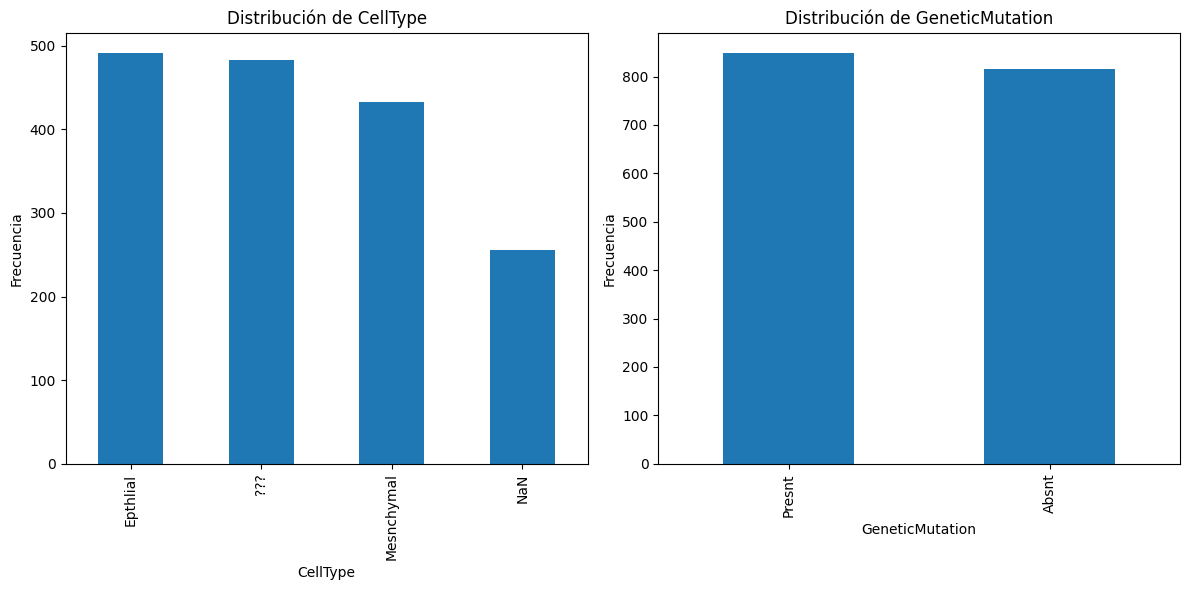

In [ ]:
categorical_columns = ["CellType", "GeneticMutation"]
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_columns), figsize=(12, 6))

for i, col in enumerate(categorical_columns):
    value_counts = balanced_dev[col].value_counts(dropna=False)
    value_counts.index = value_counts.index.fillna('NaN')
    value_counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [ ]:
numeric_df['Epthlial'] = (balanced_dev['CellType'] == 'Epthlial').astype(int)
numeric_df['Mesnchymal'] = (balanced_dev['CellType'] == 'Mesnchymal').astype(int)
numeric_df['GeneticMutation'] = (balanced_dev['GeneticMutation'] == 'Presnt').astype(int)

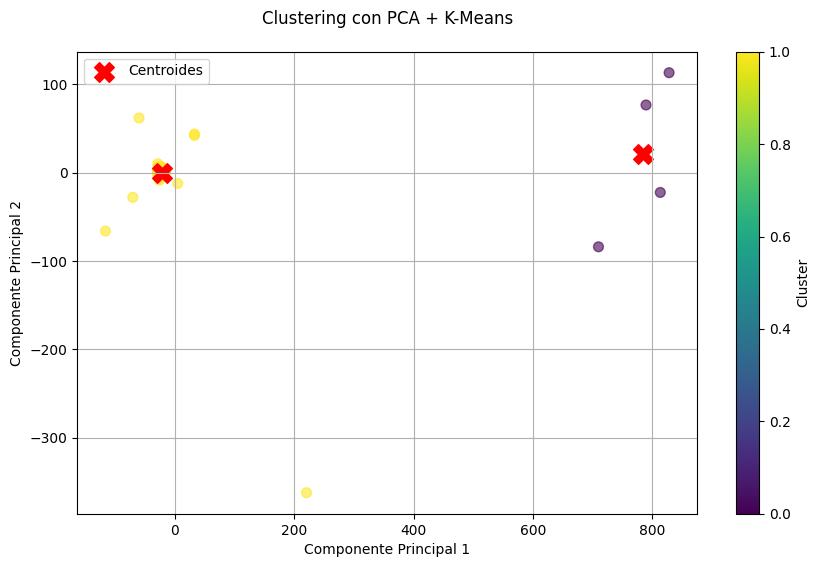

Forma de los datos originales: (150, 16)
Forma después de PCA: (150, 2)
Posiciones de los centroides:
 [[ 7.84942081e+02  2.10020402e+01]
 [-2.15052625e+01 -5.75398361e-01]]


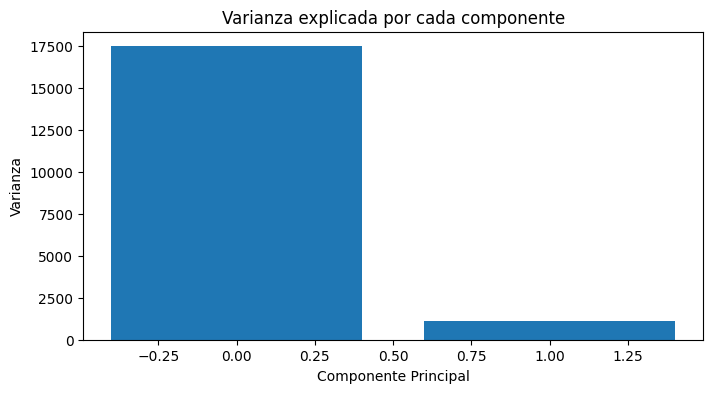

In [ ]:

X_2d, pca_components = PCA(numeric_df, n_components=2)

labels, centroids = KMeans(X_2d, n_clusters=2, random_state=42)

plot_clusters(X_2d, labels, centroids, "Clustering con PCA + K-Means")

# 5. Mostrar información adicional
print("Forma de los datos originales:", numeric_df.shape)
print("Forma después de PCA:", X_2d.shape)
print("Posiciones de los centroides:\n", centroids)

# Opcional: Visualizar componentes principales
plt.figure(figsize=(8, 4))
plt.bar(range(pca_components.shape[1]), np.var(X_2d, axis=0))
plt.title('Varianza explicada por cada componente')
plt.xlabel('Componente Principal')
plt.ylabel('Varianza')
plt.show()

## 3. Preprocesamiento de Datos

In [ ]:
X_bal = balanced_dev.drop('diagnosis', axis=1).values
y_bal = balanced_dev['diagnosis'].values

X_train, X_val, y_train, y_val = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

X_train_scaled, mean, std = standard_scaler(X_train)
X_val_scaled = (X_val - mean) / std
